In [45]:
!pip install timm
import timm
import kagglehub
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import random

In [46]:
def set_seed(seed=42):#фиксируем сиды
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [47]:
!mkdir -p ~/.kaggle && echo KGAT_9d8721813b2bf8457b054178d9c260f5 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [48]:
path = kagglehub.competition_download('dog-breed-identification')

print("Path to competition files:", path)
# path = '/Users/ilonakazanceva/.cache/kagglehub/competitions/dog-breed-identification'
print(os.listdir(path))
labels = pd.read_csv(f"{path}/labels.csv")
print(labels.head())

Path to competition files: /root/.cache/kagglehub/competitions/dog-breed-identification
['sample_submission.csv', 'train', 'labels.csv', 'test']
                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


In [49]:
train_path = os.path.join(path, "train")
test_path = os.path.join(path, "test")
print(train_path)
print(test_path)

/root/.cache/kagglehub/competitions/dog-breed-identification/train
/root/.cache/kagglehub/competitions/dog-breed-identification/test


In [50]:
#collecting full paths to images
train = []
for root, dirs, files in os.walk(train_path):
    for file in files:
        full_path = os.path.join(root, file)
        train.append(full_path)
print(len(train))
print(*train[:10], sep='\n')

10222
/root/.cache/kagglehub/competitions/dog-breed-identification/train/819f97c27a2f46f36a88d1e1cecd8e0a.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/bc408c0d39c5c9c8e184d83c45ff891a.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/f52a0aaff41a517be216bf41c967a751.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/9802d488e7a0b8b4fb04bfe2af2361f9.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/4f2d37638e34d2e896c74bbfe9bd049d.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/269a6aeefd8050aafda02044c9cd2a80.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/9e7db8711f479dfa968b2297bee33104.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/a6951e4f0cff9c000f2f112043abb085.jpg
/root/.cache/kagglehub/competitions/dog-breed-identification/train/f069ed4df76d788ff43403f1ba4fa4a8.jpg
/root/.cache/kagglehub/competitions/dog-breed-identificati

(np.float64(-0.5), np.float64(374.5), np.float64(499.5), np.float64(-0.5))

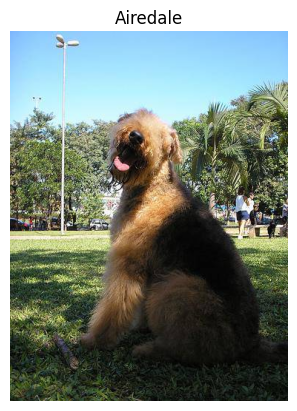

In [51]:
#это фан ячейка
i=3
img=Image.open(train[i])
img_path = train[i]
img_id = os.path.splitext(os.path.basename(img_path))[0]
plt.imshow(img)
plt.title(" ".join(labels.loc[labels['id']==img_id, "breed"].values[0].split("_")).title())
plt.axis("off")

In [52]:
encoder = LabelEncoder()
labels['breed_encoded'] = encoder.fit_transform(labels['breed']) #если дальше будем пользоваться softmax на выходе
labels.head()
labels.columns

Index(['id', 'breed', 'breed_encoded'], dtype='object')

In [53]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(384, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.12), ratio=(0.3, 3.3))
])

val_transform = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [54]:
class DogDataset(Dataset): #именно такие три функции из документации по датасетам
    def __init__(self, file_paths, labels, transform=None): #трансформ это из предыдущей ячейки преобразования над картинкой
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
    def __getitem__(self, i):
        img_path = self.file_paths[i]
        img_id = os.path.splitext(os.path.basename(img_path))[0]
        img = Image.open(img_path).convert('RGB') #перестраховочка от греха подальше
        if self.transform:
            img = self.transform(img)
        label = self.labels.loc[self.labels['id']==img_id, "breed_encoded"].values[0]
        return img, label
    def __len__(self):
        return len(self.file_paths)

In [55]:
path_to_label = dict(zip(labels['id'], labels['breed_encoded']))
train_labels_for_split = [path_to_label[os.path.splitext(os.path.basename(img_path))[0]] for img_path in train]

train_paths, val_paths = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train_labels_for_split
)
train_dataset = DogDataset(train_paths, labels, transform=train_transform) #делает датасет
val_dataset = DogDataset(val_paths, labels, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) #делает итератор над датасетом
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
print(len(train_dataset), len(val_dataset))

8177 2045


In [57]:
NUM_CLASSES = len(labels['breed'].unique())
model = timm.create_model('vit_base_patch16_384.augreg_in21k_ft_in1k', pretrained=True)#модель уже обучена на ImageNet 21к
#in_features - сколько вход у оригинального последнего слоя
model.head = nn.Linear(model.head.in_features, NUM_CLASSES) #меням на последнем слое, что у нас num_classes классов

model.safetensors:   0%|          | 0.00/347M [00:00<?, ?B/s]

In [ ]:
import copy

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(device)

checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

for name, param in model.named_parameters():
  if 'head' not in name:
    param.requires_grad = False

model = model.to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.head.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

best_val_loss = float('inf')
patience = 3
min_delta = 0.001
patience_counter = 0
best_weights = copy.deepcopy(model.state_dict())

for epoch in range(5):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels_batch in train_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() #item переводит тензор в число
        predicted = outputs.argmax(dim=1) #порода, dim1 -  ищем максимум по столбцам
        correct += (predicted == labels_batch).sum().item() #acc будет заниженым, потому что считаем только по несмешанным
        total += labels_batch.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total * 100

    model.eval() #переключаем модель в режим инференса
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels_batch in val_loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            val_loss += loss.item() #item переводит тензор в число
            predicted = outputs.argmax(dim=1) #порода, dim1 -  ищем максимум по столбцам
            val_correct += (predicted == labels_batch).sum().item()
            val_total += labels_batch.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total * 100
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}, LR: {current_lr:.6f}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}")

    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        patience_counter = 0
        best_weights = copy.deepcopy(model.state_dict())
        print('val улучшился, сохранили веса')

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, f'{checkpoint_dir}/checkpoint_epoch{epoch+1}_val{val_acc:.2f}.pth')
    else:
        patience_counter += 1
        print(f'нет улучшения, patience {patience_counter}/{patience}')
        if patience_counter >= patience:
            print(f'early stopping на эпохе {epoch+1}')
            break

model.load_state_dict(best_weights)
print(f'Первый этап. Загрузили лучшие веса с val_loss = {best_val_loss:.4f}')



for param in model.named_parameters():
    param.requires_grad = True
optimizer = optim.Adam([
    {'params': [p for n, p in model.named_parameters() if 'head' not in n], 'lr': 0.00001}, # медленный чтобы модель не забыла imagenet
    {'params': model.head_parameters(), 'lr': 0.0001}, # быстрее для обучения
])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

best_val_loss = float('inf')
patience = 3
min_delta = 0.001
patience_counter = 0
best_weights = copy.deepcopy(model.state_dict())

for epoch in range(20):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels_batch in train_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() #item переводит тензор в число
        predicted = outputs.argmax(dim=1) #порода, dim1 -  ищем максимум по столбцам
        correct += (predicted == labels_batch).sum().item() #acc будет заниженым, потому что считаем только по несмешанным
        total += labels_batch.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total * 100

    model.eval() #переключаем модель в режим инференса
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels_batch in val_loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            val_loss += loss.item() #item переводит тензор в число
            predicted = outputs.argmax(dim=1) #порода, dim1 -  ищем максимум по столбцам
            val_correct += (predicted == labels_batch).sum().item()
            val_total += labels_batch.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total * 100
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}, LR: {current_lr:.6f}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}")

    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        patience_counter = 0
        best_weights = copy.deepcopy(model.state_dict())
        print('val улучшился, сохранили веса')

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, f'{checkpoint_dir}/checkpoint_epoch{epoch+1}_val{val_acc:.2f}.pth')
    else:
        patience_counter += 1
        print(f'нет улучшения, patience {patience_counter}/{patience}')
        if patience_counter >= patience:
            print(f'early stopping на эпохе {epoch+1}')
            break

model.load_state_dict(best_weights)
print(f'Второй этап. Загрузили лучшие веса с val_loss = {best_val_loss:.4f}')


cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
def tta_predict_loader(model, test_files, device, n=5):
  tta_transform = transforms.Compose([
  transforms.Resize((384, 384)),
  transforms.RandomHorizontalFlip(p=0.1),
  transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
  ])
  model.eval()
  all_probs = []
  all_ids = []

  for img_path in test_files:
      img = Image.open(img_path).convert('RGB')
      img_id = os.path.splitext(os.path.basename(img_path))[0]
      probs_list = []

      with torch.no_grad():
          for _ in range(n):
              img_t = tta_transform(img).unsqueeze(0).to(device)
              outputs = model(img_t)
              probs = torch.softmax(outputs, dim=1)
              probs_list.append(probs.cpu().numpy())

      avg_probs = np.mean(probs_list, axis=0)[0]
      all_probs.append(avg_probs)
      all_ids.append(img_id)
  return all_probs, all_ids

In [ ]:
class DogTestDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __getitem__(self, i):
        img_path = self.file_paths[i]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        img_id = os.path.splitext(os.path.basename(img_path))[0]
        return img, img_id

    def __len__(self):
        return len(self.file_paths)

# трансформации для теста = как для валидации
test_transform = val_transform

# собираем пути к тестовым изображениям
test_files = []
for root, dirs, files in os.walk(test_path):
    for file in files:
        test_files.append(os.path.join(root, file))

test_files = sorted(test_files)

test_dataset = DogTestDataset(test_files, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# инференс

all_probs, all_ids = tta_predict_loader(model, test_files, device, n=5)
all_probs = np.array(all_probs)

# создаём submission
submission = pd.DataFrame(all_probs, columns=encoder.classes_)
submission.insert(0, "id", all_ids)

submission.to_csv("submission.csv", index=False)
print(submission.head())
print("submission.csv saved")

In [ ]:
import os
print(os.getcwd())
print(os.path.exists("submission.csv"))
from google.colab import files
files.download("/content/submission.csv")